In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Exploration and Preprocessing

In [2]:
sonar = pd.read_csv("C:/Users/shanm/Python_Practice/Datasets/sonardataset.csv")
sonar.head(3)

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R


In [3]:
sonar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [4]:
sonar.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [5]:
sonar.isna().sum()[sonar.isna().sum() > 0]

Series([], dtype: int64)

Dataset has no null values

In [6]:
sonar['Y'].value_counts()

Y
M    111
R     97
Name: count, dtype: int64

In [7]:
# Lets encode Y column

from sklearn.preprocessing import LabelEncoder
enc  = LabelEncoder()
sonar['Y'] = enc.fit_transform(sonar['Y'])
sonar.tail(2)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,0
207,0.0260,0.0363,0.0136,0.0272,0.0214,0.0338,0.0655,0.1400,0.1843,0.2354,...,0.0146,0.0129,0.0047,0.0039,0.0061,0.0040,0.0036,0.0061,0.0115,0


In [8]:
# Splitting data into X and y

X = sonar.iloc[:,:-1]
X.head(1)

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
0,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032


In [9]:
y = sonar.iloc[:,-1]
y.head(1)

0    1
Name: Y, dtype: int32

In [10]:
# Normalising featutres

from sklearn.preprocessing import MinMaxScaler
scaler  = MinMaxScaler()
X = scaler.fit_transform(X)
sonar.tail(2)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,0
207,0.0260,0.0363,0.0136,0.0272,0.0214,0.0338,0.0655,0.1400,0.1843,0.2354,...,0.0146,0.0129,0.0047,0.0039,0.0061,0.0040,0.0036,0.0061,0.0115,0


# 2. Model Implementation

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((166, 60), (42, 60), (166,), (42,))

In [13]:
from keras.models import Sequential
from keras.layers import Dense , Input
from keras.losses import mean_squared_error, mean_absolute_error

In [14]:
model1 = Sequential([
    Input(shape=(60,)),              # define input shape here
    Dense(32, activation='relu'),    # hidden layer
    Dense(1, activation='sigmoid')   # output layer
])

In [15]:
model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [16]:
# Train the model


history = model1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4394 - loss: 0.7042 - val_accuracy: 0.4706 - val_loss: 0.7000
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5379 - loss: 0.6792 - val_accuracy: 0.5294 - val_loss: 0.6833
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5455 - loss: 0.6615 - val_accuracy: 0.6176 - val_loss: 0.6621
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6439 - loss: 0.6452 - val_accuracy: 0.5882 - val_loss: 0.6649
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7197 - loss: 0.6332 - val_accuracy: 0.5882 - val_loss: 0.6524
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7424 - loss: 0.6199 - val_accuracy: 0.5882 - val_loss: 0.6430
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7045 - loss: 0.6052 - val_accuracy: 0.6765 - val_loss: 0.6305
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7121 - loss: 0.5912 - val_accuracy: 0.

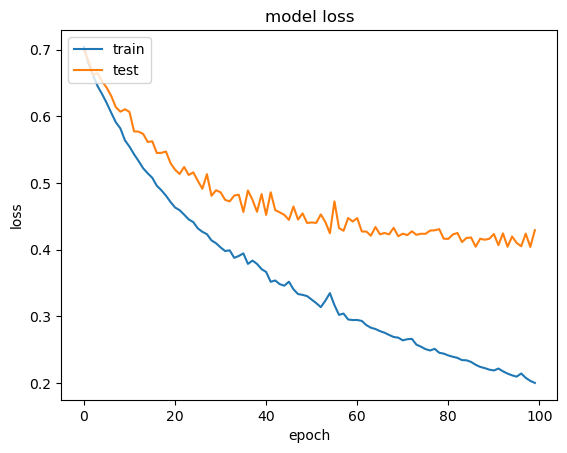

In [17]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

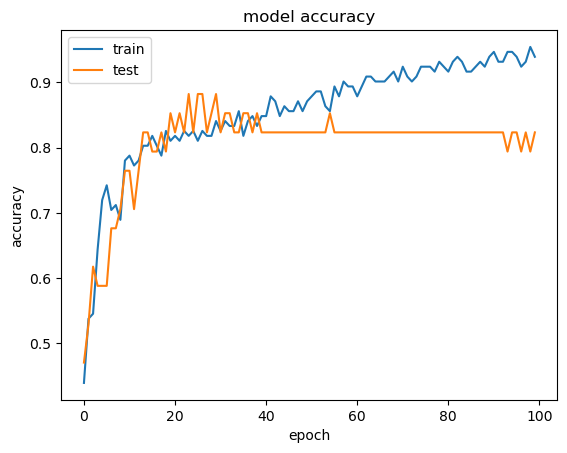

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Observations:

- No severe overfitting: Validation loss is not diverging upward, so the model isn’t memorizing training data excessively.

- Good learning progress: Both losses decrease and accuracy increases, meaning the model is improving with more epochs.

In [19]:
yhat_test = model1.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [20]:
yhat_class = (yhat_test > 0.5).astype(int).flatten()
yhat_class

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1])

# 3. Hyperparameter Tuning

In [21]:
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def create_model(neurons=32, activation='relu', learning_rate=0.001, hidden_layers=1):
    model = Sequential()
    model.add(Input(shape=(60,)))

    for _ in range(hidden_layers):
        model.add(Dense(neurons, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = KerasClassifier(model=create_model, verbose=0)

param_grid = {
    'model__neurons': [16, 32],
    'model__activation': ['relu', 'tanh'],
    'model__learning_rate': [0.001, 0.01],
    'model__hidden_layers': [1, 2],
    'batch_size': [5, 10],
    'epochs': [50]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid_result = grid.fit(X_train, y_train)

print("Best Params:", grid_result.best_params_)

Best Params: {'batch_size': 5, 'epochs': 50, 'model__activation': 'relu', 'model__hidden_layers': 2, 'model__learning_rate': 0.01, 'model__neurons': 16}


In [22]:
best_model = grid.best_estimator_

In [23]:
yhat_tunedTest = best_model.predict(X_test)

In [24]:
yhat_tunedClass = (yhat_tunedTest > 0.5).astype(int).flatten()
yhat_tunedClass

array([0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1])

# 4. Evaluation

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def eval(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

a.Evaluation of model developed without tuning

In [26]:
eval(y_test,yhat_class)

Accuracy: 0.8095238095238095
Precision: 0.6818181818181818
Recall: 0.9375
F1 Score: 0.7894736842105263
Confusion Matrix:
 [[19  7]
 [ 1 15]]


In [27]:
eval(y_test,yhat_tunedClass)

Accuracy: 0.9047619047619048
Precision: 0.8333333333333334
Recall: 0.9375
F1 Score: 0.8823529411764706
Confusion Matrix:
 [[23  3]
 [ 1 15]]


In [42]:
from sklearn.metrics import confusion_matrix,roc_auc_score,roc_curve

def plot_roc(y,yhat):
    fpr,tpr, thresh = roc_curve(y, yhat)
    auc = roc_auc_score(y, yhat)
    print(f'AUC: {auc}')
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

def plot_cm(y,yhat):
    cm = confusion_matrix(y,yhat)
    plt.figure(figsize=(2,2))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False)
    plt.show()
    plot_roc(y,yhat)

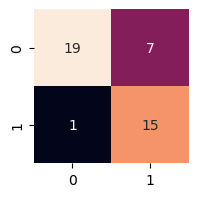

AUC: 0.8341346153846154


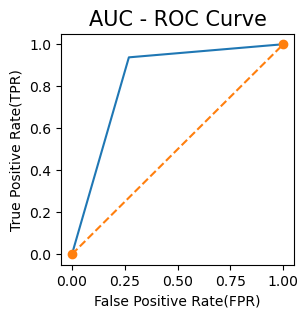

In [43]:
plot_cm(y_test,yhat_class)

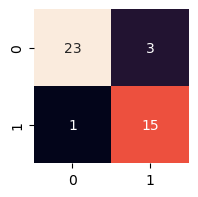

AUC: 0.9110576923076923


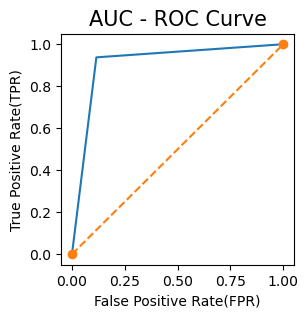

In [44]:
plot_cm(y_test,yhat_tunedClass)

Observation:

- Model without hyper parameter tuning has 80% accuracy whereas Model built with hyper parameters has 90% accuracy that is a very good score
- Precision has been increased from 68% to 83%
- F1 Score has been incraesed from 78 to 88% meaning that tuned model performs very well and whatever predicts correctly whether signal is from Mine or rock.

- Sonar signal classification is non-linear, making ANN suitable
- Feature scaling is critical
- Even small datasets benefit from careful tuning
- Overfitting is a real risk due to limited data (208 samples)

Conclusion:

- This project demonstrates how deep learning can effectively classify sonar signals into mines and rocks. Through preprocessing, ANN modeling, and systematic hyperparameter tuning, model performance improved significantly.